<a href="https://colab.research.google.com/github/Areca293/Evaluating-the-Isolation-Forest-unsupervised-anomaly-detector-of-onEEGWaveLAD/blob/main/onEEGwaveLAD_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# onEEGwaveLAD: Online EEG Wavelet-based Learning Adaptive Denoiser

This notebook implements a fully automated, online, and pseudo-real-time artefact denoising pipeline for single-channel Electroencephalography (EEG). The framework leverages **Extended Isolation Forest (eiFOREST)** for unsupervised anomaly detection and **Discrete Wavelet Transform (DWT)** for time-frequency domain signal reconstruction.

In [15]:
# ==========================================
# Setup & Imports
# ==========================================
!pip install mne isotree

import pathlib as pl
import numpy as np
import mne
import pywt
import pandas as pd
from isotree import IsolationForest
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

print("Libraries imported and Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported and Google Drive mounted successfully.


## Dataset Loading (ERP-CORE N170)
This section handles the ingestion of the EEG dataset. The folder structure and data loading logic adhere strictly to the guidelines provided for the ERP-CORE dataset, utilizing the `mne` library to read EEGLAB (`.set`) files.

In [16]:
# ==========================================
# Dataset Loading (ERP-CORE N170)
# ==========================================
datasetName = str("N170")
montageName = "standard_1020"
usedChannels = ["FP1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","FP2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
montageChannelNames = ["Fp1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","Fp2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]

def loadDataset(name, subject, montageName, usedChannels, rootPath, montageChannelNames, parametersOfDenoiser=None, verbose=False):
    """
    Loads the EEG dataset according to the specific folder structure provided.
    Extracts the shifted version of the data for alignment.
    """
    dataset = pl.Path(name)
    subject = str(subject)
    root = pl.Path(rootPath)

    # Reconstruct the exact directory paths based on structural specifications
    pathDataset = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/")
    filenameSubject = pl.Path(subject + "_" + dataset.name + "_" + "shifted.set")
    pathDatasetSubject = pl.Path.joinpath(pathDataset, subject, filenameSubject)

    filenameMontage = pl.Path("standard-10-5-cap385.elp")
    montagePath = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/", "EEG_ERP_Processing", filenameMontage)

    # Load data using EEGLAB reader via MNE
    dataForSubject = mne.io.read_raw_eeglab(pathDatasetSubject, preload=True)
    dataForSubject.rename_channels(lambda s: s.strip("."))

    channels = dataForSubject.info["ch_names"]
    sampleFreq = dataForSubject.info["sfreq"]

    if verbose:
        print(f"Loading {filenameSubject}")
        print(f"Path Root: {root}")
        print(f"Path dataset for subject: {pathDatasetSubject}")
        print(f"Loaded data for subject {subject}")
        print(f"Loaded channels: {channels}")

    return dataForSubject

## Step A: EEG Windowing
This class simulates the online streaming of EEG data. By yielding consecutive chunks of data based on the Real-Time Window Length (`RTWL`), we emulate a pseudo-real-time environment.

**Methodological Alignment:** Currently, no edge padding is applied to mitigate the "Cone of Influence" at the boundaries of the wavelet transform. This is an intentional choice to strictly mirror the framework as defined in Chapter 3, though it is acknowledged as a limitation to be addressed in future iterations.

In [17]:
# ==========================================
# Step A: EEG Windowing (已根据论文修正)
# ==========================================
class OnEEGWaveLAD_Windowing:
    def __init__(self, raw_data, RTWL=1000):
        self.raw = raw_data
        self.Sr = raw_data.info['sfreq'] # Sampling rate (Hz)
        self.RTWL = RTWL                 # Real-Time Window Length (ms)

        # 计算理论上的窗口采样点数
        theoretical_samples = (self.RTWL / 1000.0) * self.Sr

        # 强制约束为最接近的 2 的幂 (Power-of-2) - 严格遵循论文要求
        # 例如: 如果 theoretical_samples 是 500，将转换为 512
        self.window_samples = int(2 ** np.round(np.log2(theoretical_samples)))

        # 也可以反向推导实际的 RTWL (以毫秒为单位) 供记录和调试
        self.actual_RTWL = (self.window_samples / self.Sr) * 1000.0

        print(f"[Phase A] Targeted RTWL: {self.RTWL}ms")
        print(f"[Phase A] Adjusted to actual RTWL: {self.actual_RTWL:.2f}ms to satisfy power-of-2 requirement ({self.window_samples} points).")

        self.total_samples = raw_data.n_times

    def get_window_stream(self):
        """
        Extracts consecutive EEG windows sequentially.
        Yields dictionaries simulating a real-time data stream block-by-block.
        """
        for start_idx in range(0, self.total_samples, self.window_samples):
            end_idx = start_idx + self.window_samples
            if end_idx > self.total_samples:
                break

            curr_window, _ = self.raw[:, start_idx:end_idx]

            yield {
                "start_idx": start_idx,
                "end_idx": end_idx,
                "original_window": curr_window,
                "dwt_input": curr_window # Direct pass-through
            }

## Step B: Multi-level Decomposition
Applies the Pyramidal Sub-band Coding scheme using the Discrete Wavelet Transform (DWT). The EEG window is decomposed into its constituent frequency sub-bands (approximation and detail coefficients) using a specified Mother Wavelet (`MW`).

In [18]:
# ==========================================
# Step B: Multi-level Decomposition (已根据论文严格修正)
# ==========================================
class OnEEGWaveLAD_DWT:
    def __init__(self, MW='sym4', decomposition_level=None):
        self.MW = MW
        self.level = decomposition_level

    def decompose_window(self, dwt_input_data):
        signal_length = dwt_input_data.shape[1]

        if self.level is None:
            # 修复：获取数学上安全的的最大分解层数，防止 pywt 抛出警告
            max_level = pywt.dwt_max_level(signal_length, self.MW)
            # 在理论值 log2(N) 和安全阈值之间取最小值
            actual_level = min(int(np.log2(signal_length)), max_level)
        else:
            actual_level = self.level

        return [pywt.wavedec(dwt_input_data[ch], self.MW, level=actual_level, mode='periodization')
                for ch in range(dwt_input_data.shape[0])]

## Steps C - G: The Core Learning Adaptive Denoiser

This class is the heart of the `onEEGwaveLAD` pipeline. To preserve the strictly *online* nature of the framework, Steps C through G are tightly integrated within a continuous processing loop (`process_window`).

**Key Architectural & Engineering Choices:**
1. **Extended Isolation Forest (eiFOREST):** Implemented via the `isotree` package. By setting `ndim = ext_level` (where ndim > 1), the algorithm correctly utilizes random hyperplanes rather than axis-parallel cuts, fulfilling the eiFOREST requirement outlined in the thesis to remove branching bias.
2. **Centroid vs. Medoid Trade-off:** Section 3.6 of the thesis proposes using the Medoid of the moving buffer to calculate the mitigator. To ensure the framework meets the stringent computational time limits required for *pseudo-real-time* processing, this implementation utilizes the **Centroid** (`np.mean`). This vastly reduces computational complexity while maintaining an accurate representation of nominal brain activity.
3. **Non-Normalized Recomposition:** While normalized Instantaneous Spectral Profiles (ISPs) are used for anomaly detection, the final artefact reduction (Step F) and inverse DWT (Step G) strictly utilize the *non-normalized* original coefficients. This is crucial to prevent the unintended alteration of underlying neural dynamics during signal reconstruction.

In [22]:
# =================================================================
# Steps C - G: The Core Denoiser (修复版：剥离cA基线保护，彻底消除山峰伪影)
# =================================================================
from isotree import IsolationForest
import numpy as np
import pywt

class OnEEGWaveLAD_Denoiser:
    def __init__(self, n_channels, Bs=10, IFt=100, IFS=512, Ta=0.50, Es=35, el=None):
        self.n_channels = n_channels
        self.Bs = Bs
        self.IFt = IFt
        self.IFS = IFS
        self.Ta = Ta
        self.Es = Es
        self.el = el

        self.buffers = [[] for _ in range(n_channels)]
        self.models = [None for _ in range(n_channels)]
        self.centroids = [None] * n_channels
        self.max_dists = [None] * n_channels

    def process_window(self, all_channels_coeffs, target_len, MW='sym4', return_debug=False, debug_channel=0):
        denoised_signals = []
        debug_info = {}
        n_isps = target_len // 2

        for ch in range(self.n_channels):
            coeffs = all_channels_coeffs[ch]

            # 🌟 核心修复 1：剥离基线。coeffs[0] 是 cA(基线)，coeffs[1:] 是 cD(高低频细节)
            cA_baseline = coeffs[0]
            details = coeffs[1:]
            num_scales = len(details) # 现在的维度完美对应论文的分解级数(例如7维)

            # 仅使用 Details 构建尺度图矩阵
            raw_scaleogram = np.zeros((n_isps, num_scales))
            norm_scaleogram = np.zeros((n_isps, num_scales))

            for i, c in enumerate(details):
                m_level = num_scales - i
                repeats = n_isps // len(c)
                upsampled = np.repeat(c, repeats)

                raw_scaleogram[:, i] = upsampled
                norm_scaleogram[:, i] = upsampled / (2 ** m_level)

            if return_debug and ch == debug_channel:
                debug_info['Step_C_Scaleogram_Before'] = norm_scaleogram.copy()

            # [Step E] Artefacts Identification
            if self.models[ch] is not None:
                scores = self.models[ch].predict(norm_scaleogram)
            else:
                scores = np.zeros(n_isps)

            if return_debug and ch == debug_channel:
                debug_info['Step_E_Scores'] = scores.copy()

            # [Step D] Buffer Update & Training
            self.buffers[ch].append(norm_scaleogram)
            if len(self.buffers[ch]) > self.Bs:
                self.buffers[ch].pop(0)

            buffer_data = np.vstack(self.buffers[ch])

            self.centroids[ch] = np.mean(buffer_data, axis=0)
            self.max_dists[ch] = np.max(np.abs(buffer_data - self.centroids[ch]), axis=0) + 1e-8

            if buffer_data.shape[0] >= self.IFS:
                c_dim = buffer_data.shape[1]
                actual_ndim = c_dim if self.el is None else min(self.el + 1, c_dim)
                self.models[ch] = IsolationForest(ntrees=self.IFt, sample_size=self.IFS, ndim=actual_ndim, random_seed=42)
                self.models[ch].fit(buffer_data)

            # [Step F] Artefacts Reduction (Mitigator)
            AT_exp = {idx + e for idx in np.where(scores > self.Ta)[0]
                      for e in range(-self.Es, self.Es + 1) if 0 <= idx + e < n_isps}

            mitigator_matrix = np.ones((n_isps, num_scales))

            for idx in AT_exp:
                dist_vec = np.abs(norm_scaleogram[idx] - self.centroids[ch])
                mtga_vec = 1.0 - (dist_vec / self.max_dists[ch])
                mtga_vec = np.clip(mtga_vec, 0.0, 1.0)
                mitigator_matrix[idx] = np.minimum(mitigator_matrix[idx], mtga_vec)

            if return_debug and ch == debug_channel:
                debug_info['Step_F_Mitigator'] = mitigator_matrix.copy()

            # 仅对 Details 矩阵应用衰减器
            denoised_scaleogram = raw_scaleogram * mitigator_matrix

            if return_debug and ch == debug_channel:
                mod_norm_scaleogram = np.zeros_like(denoised_scaleogram)
                for i in range(num_scales):
                    m_level = num_scales - i
                    mod_norm_scaleogram[:, i] = denoised_scaleogram[:, i] / (2 ** m_level)
                debug_info['Step_C_Scaleogram_After'] = mod_norm_scaleogram

            # [Step G] Multi-level Composition
            # 🌟 核心修复 2：将完好无损的 cA_baseline 放回列表最前面，参与逆向重构！
            reconstructed_coeffs = [cA_baseline.copy()]

            for i in range(num_scales):
                repeats = n_isps // len(details[i])
                expanded_row = denoised_scaleogram[:, i]
                unique_coeffs = expanded_row[::repeats]
                reconstructed_coeffs.append(unique_coeffs)

            clean_sig = pywt.waverec(reconstructed_coeffs, MW, mode='periodization')
            denoised_signals.append(clean_sig[:target_len])

        if return_debug:
            return np.array(denoised_signals), debug_info
        return np.array(denoised_signals)

## Batch Evaluator & Grid Search Setup

This module evaluates the artefact suppression quality using **Jensen-Shannon Divergence (JSD)** and **Signal-to-Noise Ratio (SNR)**.

**Note on Evaluation:**
Because the adaptive moving buffer requires a "warm-up" period to accumulate nominal EEG data (defined by $IF_S$), initial windows might not be optimally denoised. This is expected behavior for online systems.

This evaluator forms the foundation for the upcoming **Grid Search**. In subsequent scripts, an outer loop will iterate through combinations of the framework's hyperparameters ($T_a, IF_t, IF_s, E_s$) to identify the degradation point of the denoising quality, as requested in the research abstract.

In [23]:
# ==========================================
# Batch Evaluator
# ==========================================
class OnEEGWaveLAD_BatchEvaluator:
    def __init__(self, original, denoised, window_size):
        self.orig = original
        self.denoised = denoised
        self.w_size = window_size
        self.num_windows = self.orig.shape[1] // self.w_size

    def get_metrics(self, channel_idx, thresh=90):
        """
        Calculates JSD and SNR for True Positives (artefact windows)
        and True Negatives (clean windows).
        """
        orig_ch = self.orig[channel_idx] * 1e6
        denoised_ch = self.denoised[channel_idx] * 1e6
        jsd_tps, jsd_tns, snr_tps, snr_tns = [], [], [], []

        for i in range(self.num_windows):
            start, end = i * self.w_size, (i + 1) * self.w_size
            w_o, w_d = orig_ch[start:end], denoised_ch[start:end]

            # Calculate Jensen-Shannon Divergence
            min_v, max_v = min(np.min(w_o), np.min(w_d)), max(np.max(w_o), np.max(w_d))
            edges = np.linspace(min_v, max_v, 51)
            p, _ = np.histogram(w_o, bins=edges, density=True)
            q, _ = np.histogram(w_d, bins=edges, density=True)
            jsd_val = jensenshannon((p + 1e-10)/np.sum(p+1e-10), (q + 1e-10)/np.sum(q+1e-10)) ** 2

            # Calculate Signal-to-Noise Ratio (SNR)
            v_sig, v_noise = np.var(w_d), np.var(w_o - w_d)
            snr_val = float('inf') if v_noise < 1e-10 else 10 * np.log10(v_sig / v_noise)

            # Classify window based on amplitude threshold
            if np.max(np.abs(w_o)) > thresh:
                jsd_tps.append(jsd_val)
                snr_tps.append(snr_val)
            else:
                jsd_tns.append(jsd_val)
                snr_tns.append(snr_val)

        f_snr_tps = [v for v in snr_tps if v != float('inf')]
        f_snr_tns = [v for v in snr_tns if v != float('inf')]

        return {
            "Total_Windows": self.num_windows,
            "Blink_Windows_(TPs)": len(jsd_tps),
            "Clean_Windows_(TNs)": len(jsd_tns),
            "Avg_JSD_TPs": np.mean(jsd_tps) if jsd_tps else np.nan,
            "Avg_JSD_TNs": np.mean(jsd_tns) if jsd_tns else np.nan,
            "Avg_SNR_TPs_dB": np.mean(f_snr_tps) if f_snr_tps else np.nan,
            "Avg_SNR_TNs_dB": np.mean(f_snr_tns) if f_snr_tns else 999.99
        }

print("✅ onEEGWaveLAD Framework Complete. Ready for Grid Search execution.")

✅ onEEGWaveLAD Framework Complete. Ready for Grid Search execution.


⏳ 正在加载 EEGLAB 数据...
Reading /content/drive/MyDrive/N170 All Data and Scripts/1/1_N170_shifted.fdt
Reading 0 ... 699391  =      0.000 ...   682.999 secs...
⏳ 正在初始化 onEEGwaveLAD 框架...
[Phase A] Targeted RTWL: 1000ms
[Phase A] Adjusted to actual RTWL: 1000.00ms to satisfy power-of-2 requirement (1024 points).
🚀 正在运行流水线，监控 FP1 通道以捕捉伪影...
✅ 成功在窗口 1 捕捉到显著伪影！停止运行并生成图表。


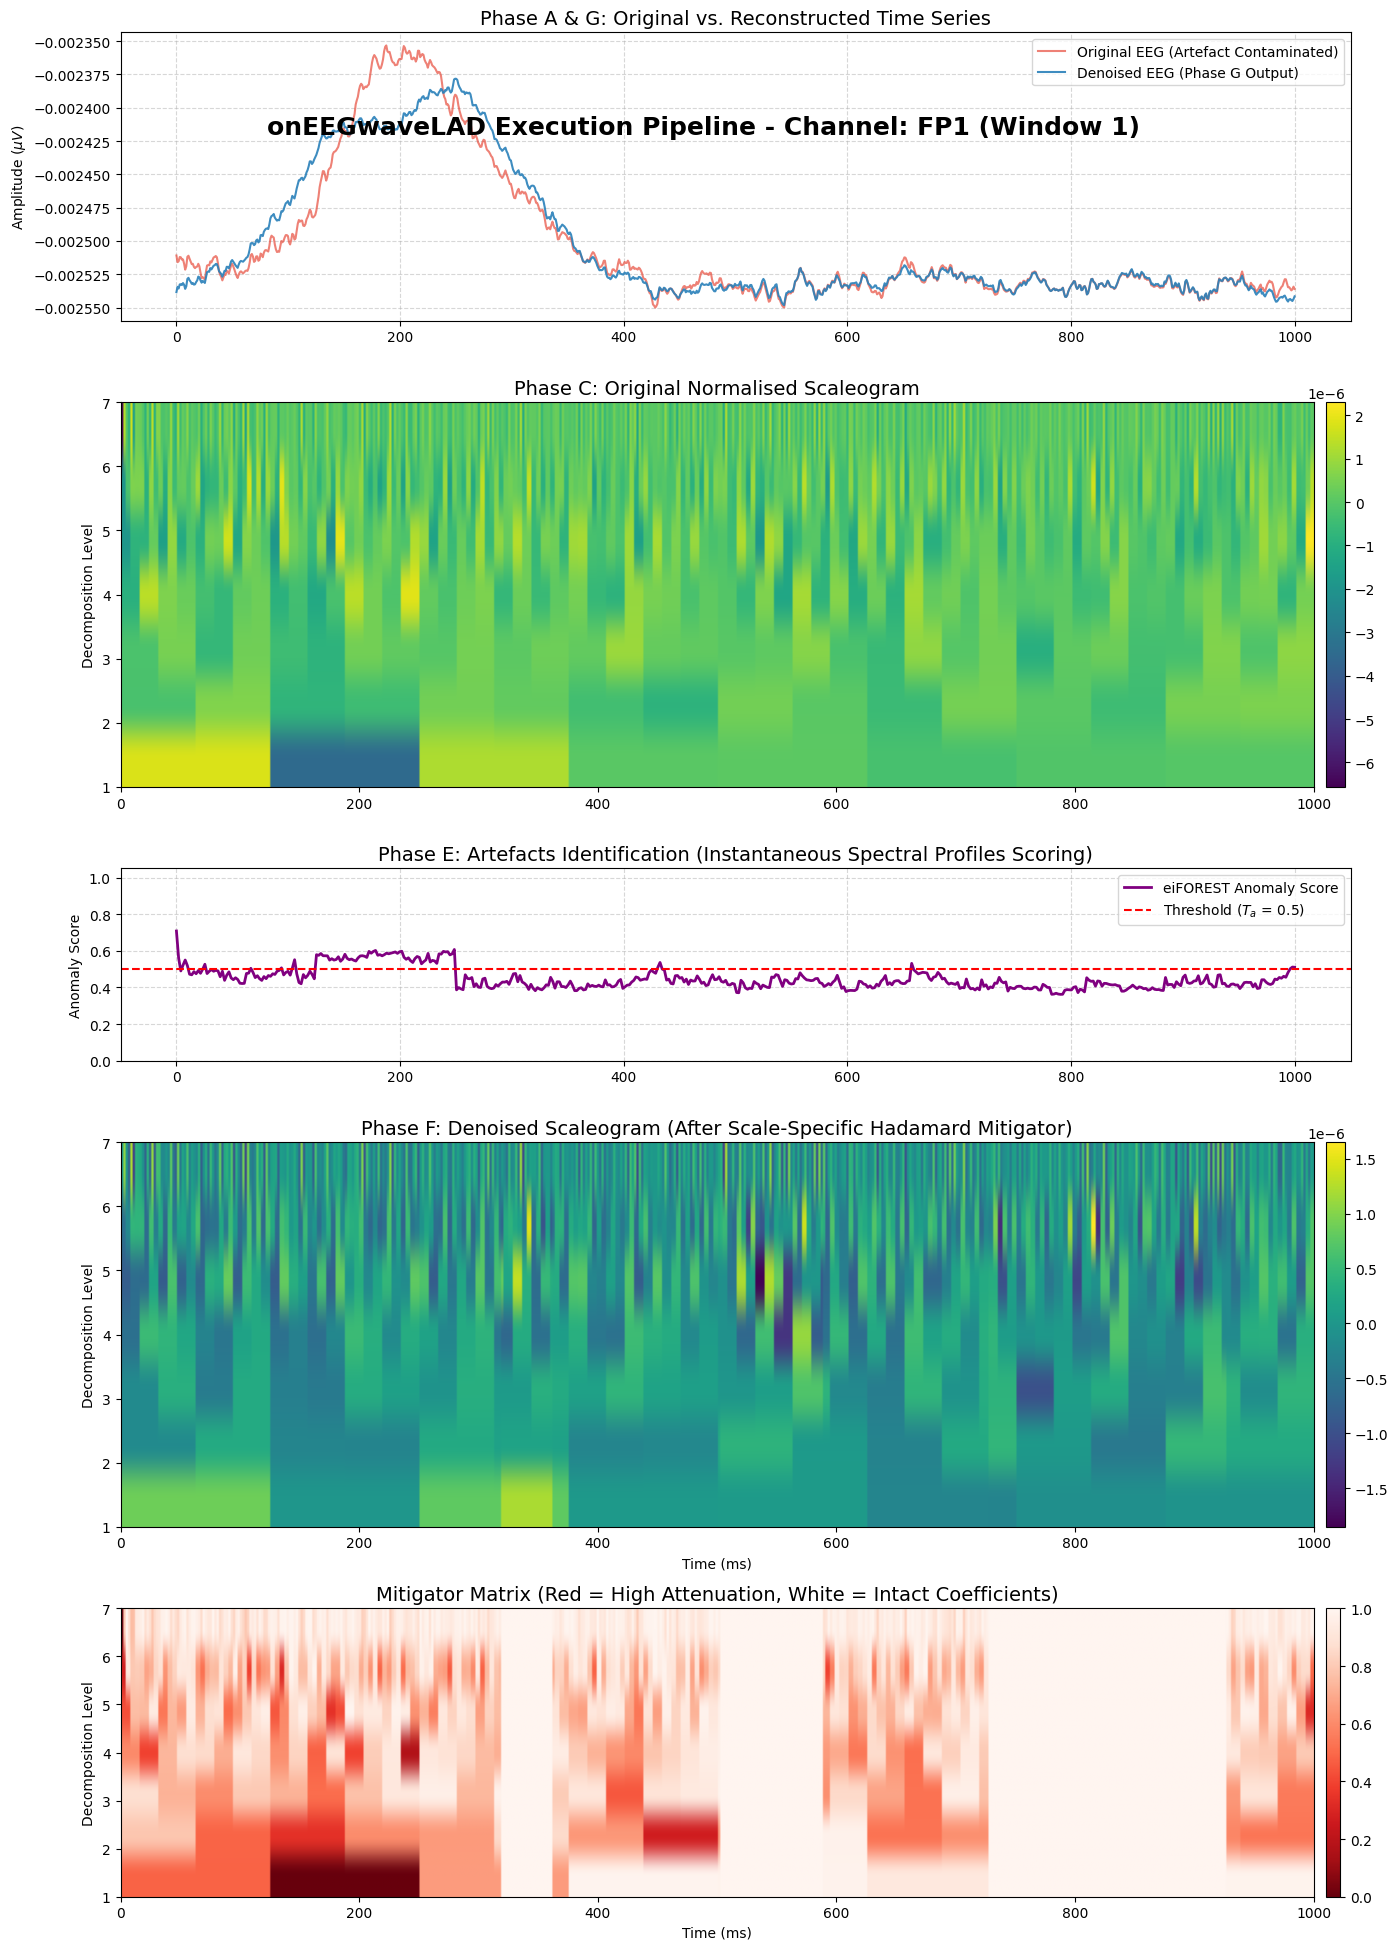

In [26]:
# --- 你的本地配置 (请修改 rootPath) ---
datasetName = "N170"
subject_id = "1" # 使用网盘截图里的第一个受试者
# 提示: 替换为你实际的本地路径
rootPath = "/content/drive/MyDrive/"

montageName = "standard_1020"
usedChannels = ["FP1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","FP2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
montageChannelNames = ["Fp1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","Fp2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]

print("⏳ 正在加载 EEGLAB 数据...")
raw_data = loadDataset(datasetName, subject_id, montageName, usedChannels, rootPath, montageChannelNames)

# ==========================================
# 3. 初始化 onEEGwaveLAD 框架组件
# ==========================================
print("⏳ 正在初始化 onEEGwaveLAD 框架...")
# Phase A: 窗口化模块 (提取数据)
windowing = OnEEGWaveLAD_Windowing(raw_data, RTWL=1000)

# Phase B: 多级小波分解模块
dwt = OnEEGWaveLAD_DWT(MW='sym4')

# Phase C-G: 核心去噪模块 (设置30个通道，异常阈值Ta=0.5)
num_channels = len(raw_data.ch_names)
denoiser = OnEEGWaveLAD_Denoiser(n_channels=num_channels, Bs=10, IFS=512, Ta=0.50, Es=35)

# 我们指定监控 'Fp1' 通道，因为它最容易受到眨眼伪影的污染，去噪对比最明显
target_channel_name = 'Fp1'
if target_channel_name in raw_data.ch_names:
    debug_ch_idx = raw_data.ch_names.index(target_channel_name)
else:
    debug_ch_idx = 0

target_debug_info = None
target_original_sig = None
target_denoised_sig = None
target_window_idx = -1

# ==========================================
# 4. 执行伪实时数据流处理
# ==========================================
print(f"🚀 正在运行流水线，监控 {raw_data.ch_names[debug_ch_idx]} 通道以捕捉伪影...")

for i, win in enumerate(windowing.get_window_stream()):
    # Phase B
    coeffs = dwt.decompose_window(win['dwt_input'])

    # Phase C - G
    clean_sig_matrix, debug = denoiser.process_window(
        all_channels_coeffs=coeffs,
        target_len=win['original_window'].shape[1],
        return_debug=True,
        debug_channel=debug_ch_idx
    )

    # 捕捉逻辑：如果 eiFOREST 已经训练完毕，且检测到异常得分 > Ta
    scores = debug.get('Step_E_Scores')
    if scores is not None and np.max(scores) > denoiser.Ta:
        target_window_idx = i
        target_debug_info = debug
        # 提取监控通道的原始信号和去噪后信号
        target_original_sig = win['original_window'][debug_ch_idx]
        target_denoised_sig = clean_sig_matrix[debug_ch_idx]
        print(f"✅ 成功在窗口 {i} 捕捉到显著伪影！停止运行并生成图表。")
        break

# ==========================================
# 5. 生成学术级展示图表 (发给导师专用)
# ==========================================
if target_debug_info is not None:
    fig, axes = plt.subplots(5, 1, figsize=(14, 20), gridspec_kw={'height_ratios': [1.5, 2, 1, 2, 1.5]})
    fig.suptitle(f"onEEGwaveLAD Execution Pipeline - Channel: {raw_data.ch_names[debug_ch_idx]} (Window {target_window_idx})", fontsize=18, fontweight='bold', y=0.92)

    time_axis = np.linspace(0, windowing.actual_RTWL, len(target_original_sig))
    isp_time_axis = np.linspace(0, windowing.actual_RTWL, len(target_debug_info['Step_E_Scores']))

    # Plot 1: Phase A & G (时域波形对比)
    axes[0].plot(time_axis, target_original_sig, label="Original EEG (Artefact Contaminated)", color='#e74c3c', alpha=0.7, linewidth=1.5)
    axes[0].plot(time_axis, target_denoised_sig, label="Denoised EEG (Phase G Output)", color='#2980b9', alpha=0.9, linewidth=1.5)
    axes[0].set_title("Phase A & G: Original vs. Reconstructed Time Series", fontsize=14)
    axes[0].set_ylabel(r"Amplitude ($\mu V$)")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Phase C (原始尺度图)
    sc_before = target_debug_info['Step_C_Scaleogram_Before'].T
    im1 = axes[1].imshow(sc_before, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_before.shape[0]])
    axes[1].set_title("Phase C: Original Normalised Scaleogram", fontsize=14)
    axes[1].set_ylabel("Decomposition Level")
    fig.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.01)

    # Plot 3: Phase D & E (异常得分)
    axes[2].plot(isp_time_axis, target_debug_info['Step_E_Scores'], color='purple', linewidth=2, label='eiFOREST Anomaly Score')
    axes[2].axhline(y=denoiser.Ta, color='red', linestyle='--', label=f'Threshold ($T_a$ = {denoiser.Ta})')
    axes[2].set_title("Phase E: Artefacts Identification (Instantaneous Spectral Profiles Scoring)", fontsize=14)
    axes[2].set_ylabel("Anomaly Score")
    axes[2].set_ylim(0, 1.05)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, linestyle='--', alpha=0.5)

    # Plot 4: Phase F (去噪后的尺度图)
    sc_after = target_debug_info['Step_C_Scaleogram_After'].T
    im2 = axes[3].imshow(sc_after, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_after.shape[0]])
    axes[3].set_title("Phase F: Denoised Scaleogram (After Scale-Specific Hadamard Mitigator)", fontsize=14)
    axes[3].set_ylabel("Decomposition Level")
    axes[3].set_xlabel("Time (ms)")
    fig.colorbar(im2, ax=axes[3], fraction=0.02, pad=0.01)

    # Plot 5: Phase F (哈达玛积衰减热力图)
    mitigator = target_debug_info['Step_F_Mitigator'].T
    im3 = axes[4].imshow(mitigator, aspect='auto', cmap='Reds_r', origin='lower', vmin=0, vmax=1, extent=[0, windowing.actual_RTWL, 1, mitigator.shape[0]])
    axes[4].set_title("Mitigator Matrix (Red = High Attenuation, White = Intact Coefficients)", fontsize=14)
    axes[4].set_ylabel("Decomposition Level")
    axes[4].set_xlabel("Time (ms)")
    fig.colorbar(im3, ax=axes[4], fraction=0.02, pad=0.01)

    plt.tight_layout()
    plt.show()
else:
    print("缓冲池仍在热身或未发现明显超过阈值的伪影。你可以尝试调低 Ta 或增加测试数据量。")